# Transformers: Voice recognition

The purpose of this assignment was to utilize different pretrained Whisper-models to recognize spoken finnish speech. "Large" and "tiny" models were chosen, since the difference in processing speed and performance should be quite notable.

Four voice samples were tested with both models.

- A sample of clearly articulated literary finnish without any other sounds.
- A sample of two finnish speakers speaking with a noticable dialect
- A sample of clearly articulated literary finnish with music in the background.
- A sample of an english speaker telling a story in english.

The samples are processed and transcribed in this order.

## Prepararing the audio files

In [28]:
import torch
import time
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration

audio_files = ["audio/Selkeä.mp3", "audio/Murre_kaksi_puhujaa.mp3", "audio/Taustamusiikkia.mp3", "audio/Englanti.mp3"]

One of the samples is loaded and some of its metadata and audio player presented. These were used to verify that the audio files load correctly.

In [29]:
y, sr = librosa.load(audio_files[0], sr=16000)
display(Audio(y, rate=sr))

duration = librosa.get_duration(y=y, sr=sr)
print(f"\nAudio Statistics:")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample rate: {sr} Hz")


Audio Statistics:
Duration: 23.29 seconds
Sample rate: 16000 Hz


The waveform of one of the audio samples along with its melspectrogram are shown below. These representations illustrate the audio signal's amplitude over time and its frequency characteristics across different frequency bands. The melspectrogram is needed to convert the raw audio waveform into a 2D time-frequency representation that captures the essential acoustic features of the speech. The Whisper models require this because they need a input format that resembles an image. They cannot work with raw audio files.

The features of the melspectrogram can be interpreted as follows:

    -X-axis (Time): Represents the duration of the audio signal, advancing from left to right.

    -Y-axis (Frequency): Represents the frequency components of the audio at a point in time, ascending from low frequencies at the bottom to high frequencies at the top.

    -Color (Magnitude): Represents the amplitude of the audio signal at a specific frequency and time. Brighter colors indicate higher energy and louder sounds, while darker colors represent quieter sounds.

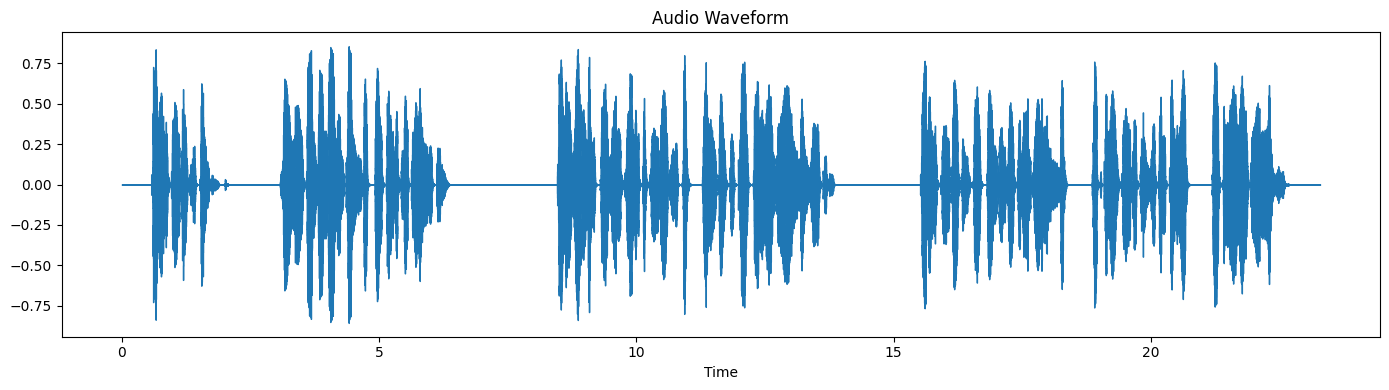

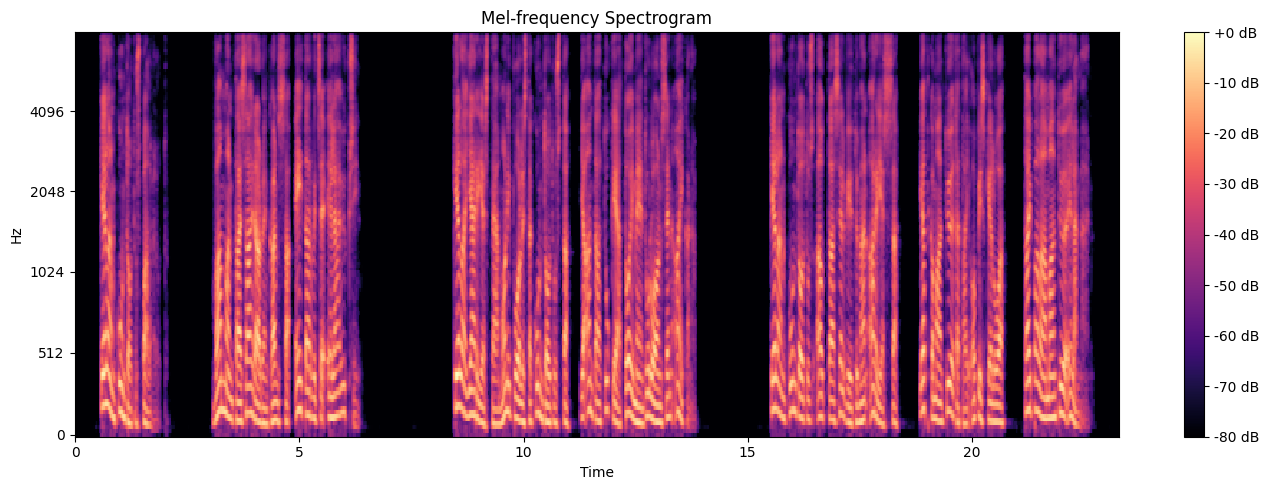

In [30]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, y_axis='mel', x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram')
plt.tight_layout()
plt.show()

The audio files are loaded into a list

In [31]:
y_list = []

for audio in audio_files:
    y, sr = librosa.load(audio, sr=16000)
    y_list.append(y)

## Prepararing the models

Both models are loaded an initialized to transcribe finnish text.

In [14]:
device = "cpu"

model_name_large = f"openai/whisper-large"
model_name_tiny = f"openai/whisper-tiny"
processor_large = WhisperProcessor.from_pretrained("openai/whisper-large")
processor_tiny = WhisperProcessor.from_pretrained("openai/whisper-tiny")

model_large = WhisperForConditionalGeneration.from_pretrained(model_name_large).to(device)
model_tiny = WhisperForConditionalGeneration.from_pretrained(model_name_tiny).to(device)

forced_decoder_ids = processor_large.get_decoder_prompt_ids(language="fi", task="transcribe")
forced_decoder_ids = processor_tiny.get_decoder_prompt_ids(language="fi", task="transcribe")

C:\Users\aaroj\anaconda3\envs\keras\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aaroj\.cache\huggingface\hub\models--openai--whisper-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 167/167 [00:00<00:00, 5243.00it/s]


## Trascription the audio files

A function is created to simplify transcription of multiple sound files in the next step.

In [16]:
def transcribe_audio(y, sr, processor, model):
    print("Processing audio...")
    input_features = processor(
        y, 
        sampling_rate=sr, 
        return_tensors="pt"
    ).input_features.to(device)

    print("Generating transcription...")
    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            language="fi",
            task="transcribe"
        )

    transcription = processor.batch_decode(
        generated_ids, 
        skip_special_tokens=True
    )[0]

    return transcription

Each one of the four audio files are transcribed using both the large and the tiny Whiper-models. The trascriptions can be found below.

In [32]:
print("--- Starting Large Model Transcription ---")
start_time = time.perf_counter()

for y in y_list:
    print(transcribe_audio(y, 16000, processor_large, model_large))
    print()
    
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"-> Finished large in {elapsed_time:.4f} seconds.")

print("\n--- Starting Tiny Model Transcription ---")
start_time = time.perf_counter()

for y in y_list:
    print(transcribe_audio(y, 16000, processor_tiny, model_tiny))
    print()
    
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"-> Finished tiny in {elapsed_time:.4f} seconds.")

--- Starting Large Model Transcription ---
Processing audio...
Generating transcription...
 Kelan kuntoutuspalvelut. Vamman tai sairauden kanssa ei tarvitse elää yksin. Kela järjestää monipuolista kuntoutusta ja antaa tukea toimeentuloon sen aikana. Kelan kuntoutus auttaa selviytymään arjessa, jatkamaan työtä tai opiskelua tai palaamaan työelämään.

Processing audio...
Generating transcription...
 Mitä sulle kuuluu? Ihan hyvää. Meillä oli ne Markon juhulat viime viikonloppuna. Harmi kun näit pääs sun mukaan. No niin. Mulla oli aika paljon hommaa, niin en päässyt. Tekkiikö näitä kouluhommia? Joo, mä tekkiin... Mulla on yksi aika vaikea tentti.

Processing audio...
Generating transcription...
 Moi! Haluatko oppia suomea? Hyvä! Seuraa vain minua ja minun opetusvideoita. Minä olen Jenni ja olen suomen kielen opettaja.

Processing audio...
Generating transcription...
 Viime viikkoa viikkoiluun, katsottin Englandia ensimmäisen kertaan. Pidin siellä 20 päivää. Yksi päivä, kun kävin Liverpooli

Below are the actual transcriptions:

Kelan kuntoutuspalvelut. Vamman tai sairauden kanssa ei tarvitse elää yksin. Kela järjestää monipuolista kuntoutusta ja antaa tukea toimeentuloon sen aikana. Kelan kuntoutus auttaa selviytymään arjessa, jatkamaan työtä tai opiskelua tai palaamaan työelämään.

Mitä sulle kuuluu? Iha hyvvää. Meillä oli ne Markon juhulat viime viikonloppuna. Harmi ku nä et päässy mukkaan. No niin! Mulla oli aika paljo hommaa nii en päässy. Nii. Tekkiikkö nää jotain kouluhommia? Joo mää tekkiin. Mul o yks aika vaikia tentti.

Moi. Haluatko oppia suomea? Hyvä. Seuraa vain minua ja minun opetusvideoita. Minä olen Jenni ja olen suomen kielen opettaja.

Last summer vacation, I visited England for the first time. I stayed there for twenty days. One day when I was walking around Liverpool, enjoying the weather, shopping and taking pictures, I started to feel a bit tired and hungry.

When analyzing the transcripts side by side with the large Whisper-model transcriptions, the first and third texts are practically identical to the reference transcript, while the second contains minor variations due to difficult dialect-specific vocabulary that the model still partially interprets correctly. The final transcription shows the largest variance, which is expected since the source audio was in English but the model was configured to transcribe Finnish speech. Despite this language mismatch, the model successfully captures several words and contextual meanings, demonstrating a surprisingly robust performance since this requires translating as well as transcribing the text simultaneously.

In turn when analyzing the tiny Whisper-model, we observe a noticeable decrease in accuracy compared to the large model across all four files. The first transcription remains generally understandable but contains minor typographical and grammatical errors, while the second struggles significantly with the regional dialect, resulting in fragmented and largely incorrect interpretations of the conversational speech. The third transcription captures the general intent and most individual words, though messed up with some relatively easy words. Finally, when tasked with the English audio file, the tiny model fails completely, entering a repetitive hallucination loop of continuous phrases.

## Discussion

The purpose of the assignment was to compare the performance of large and tiny pretrained Whisper models on voice recognition tasks in the Finnish language. The comparison highlights how model size and computational demands affect transcription quality across different audio conditions.

On clean and clearly articulated literary Finnish, the large Whisper model demonstrated high accuracy and reliable transcription. The tiny model, while faster, produced minor typographical and grammatical errors on the same clean audio. The difference in performance becomes more significant when processing speech with regional dialects. The large model maintained a high level of comprehension, whereas the tiny model struggled, resulting in fragmented and incorrect interpretations.

Testing the models with background noise showed that the large model is more robust when filtering out background music, while the tiny model captures the intent but misses individual words. When tested with an English audio file, the tiny model was unable to process the audio correctly and entered a repetitive hallucination loop of continuous phrases, whereas the large model successfully transcribed the English speech.

Overall, the assignment demonstrates the expected trade-off between processing speed and recognition quality. While the tiny model is more efficient, the large model is significantly more robust and better suited for multi-speaker inputs, conversational dialects, and audio containing background noise.